In [1]:
from fastDSA.simdist import SimDistConfig, FastDSASimilarity
import numpy as np
from scipy.integrate import solve_ivp

In [2]:
use_synthetic = True  # <-- set to False to load from folders

folder_A = "/home/behradarm/Documents/fastDSA/fastDSA_EEG/out/post_stimulus/"   # folder of .npy files for Dataset A (if not synthetic)
folder_B = "/home/behradarm/Documents/fastDSA/fastDSA_EEG/out/pre_stimulus/"   # folder of .npy files for Dataset B (if not synthetic)

def load_trajs_from_folder(folder: str):
    """Load all .npy files in a folder as a list of arrays (T, n_features).\"\"\"\"\"\""""
    path = Path(folder)
    if not path.exists():
        raise FileNotFoundError(f"Folder not found: {folder}")
    trajs = []
    for f in sorted(path.glob("*.npy")):
        arr = np.load(f, allow_pickle=False)
        if arr.ndim != 2:
            raise ValueError(f'File {f} must be 2D (T, n_features). Got shape {arr.shape}.' )
        trajs.append(arr)
    if len(trajs) == 0:
        raise ValueError(f'No .npy files found in {folder}')
    return trajs

# --- Synthetic demo systems (2D) ---
def system_a(t, state, eps=0.5):
    x, y = state
    dx = -1.0 * x + eps * x * y
    dy = -2.0 * y - eps * x**2
    return [dx, dy]

def system_b(t, state, eps=0.5):
    x, y = state
    dx = -1.5 * x + 0.5 * y - eps * x**2
    dy = 0.5 * x - 1.5 * y - eps * y**2
    # dx = -1.0 * x + eps * x * y
    # dy = -3.0 * y - eps * x**2
    return [dx, dy]

def generate_trajectory(system, x0, T=10.0, dt=0.01, eps=0.5):
    t_eval = np.arange(0, T, dt)
    sol = solve_ivp(system, (0, T), x0, t_eval=t_eval, args=(eps,))
    return sol.y.T  # (T, 2)

if use_synthetic:
    # Build small demo sets
    num_per_set = 10
    T=10.0; dt=0.01
    eps=0.5
    rng = np.random.default_rng(42)

    dataset_A = [generate_trajectory(system_a, rng.uniform(-4,4,size=2), T=T, dt=dt, eps=eps) for _ in range(num_per_set)]
    dataset_B = [generate_trajectory(system_b, rng.uniform(-4,4,size=2), T=T, dt=dt, eps=eps) for _ in range(num_per_set)]
else:
    dataset_A = load_trajs_from_folder(folder_A)
    dataset_B = load_trajs_from_folder(folder_B)

print(f"Loaded {len(dataset_A)} trajectories for A, {len(dataset_B)} for B.")
print(f'Example shape A[0]: {dataset_A[0].shape}.')

Loaded 10 trajectories for A, 10 for B.
Example shape A[0]: (1000, 2).


In [3]:
import numpy as np
import torch
from time import time

# package imports
from fastDSA.simdist import SimDistConfig, FastDSASimilarity


def to_channels_time(traj_Tn: np.ndarray) -> np.ndarray:
    """
    Convert (T, n_features) -> (channels, timepoints).
    Your package expects (channels, timepoints).
    """
    if traj_Tn.ndim != 2:
        raise ValueError(f"Trajectory must be 2D (T, n_features). Got {traj_Tn.shape}")
    return traj_Tn.T


# Convert your datasets
dataset_A_ct = [to_channels_time(tr) for tr in dataset_A]
dataset_B_ct = [to_channels_time(tr) for tr in dataset_B]

print("A example (C,T):", dataset_A_ct[0].shape)
print("B example (C,T):", dataset_B_ct[0].shape)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


def run_one(method: str, iters=300, lr=1e-2, n_delays=20, delay_interval=1, rank=None):
    cfg = SimDistConfig(
        n_delays=n_delays,
        delay_interval=delay_interval,
        rank=rank,                 # None triggers SVHT global rank
        method=method,
        iters=iters,
        lr=lr,
        eta=None,                  # for land, defaults to lr in simdist
        gamma=0.98,
        n_Cmats=2,
        device=device,
        verbose=True,
    )
    sim = FastDSASimilarity(cfg)

    t0 = time()
    score, used_rank = sim.fit_score(dataset_A_ct, dataset_B_ct)
    dt = time() - t0

    print(f"\n=== method={method} ===")
    print("score:", score)
    print("used_rank:", used_rank)
    print("elapsed (s):", round(dt, 3))
    return score, used_rank


# Keep it light at first
scores = {}
for m in ["ro", "rim", "land"]:
    scores[m] = run_one(m, iters=200, lr=1e-2, n_delays=15, delay_interval=1, rank=None)

# Optional: kw (only if kooplearn import is fixed in kwdsa.py)
# scores["kw"] = run_one("kw", iters=0, lr=0, n_delays=15, delay_interval=1, rank=None)

print("\nDone. Scores:", scores)


A example (C,T): (2, 1000)
B example (C,T): (2, 1000)
Using device: cuda
[fastDSA] Detected global rank via SVHT: 14
Optimal C computed for group O(n) with regularization and low-rank approximation.

=== method=ro ===
score: 1.3456069231033325
used_rank: 14
elapsed (s): 1.523
[fastDSA] Detected global rank via SVHT: 14
[Landing] iter=1/200 loss=1.772424e+00
[Landing] iter=101/200 loss=1.009860e+00
[Landing] iter=200/200 loss=8.786054e-01
[Landing] score=0.975115, time=0.132s

=== method=rim ===
score: 0.9751150012016296
used_rank: 14
elapsed (s): 0.173
[fastDSA] Detected global rank via SVHT: 14


100%|██████████| 200/200 [00:00<00:00, 1731.80it/s]


=== method=land ===
score: 1.002195954322815
used_rank: 14
elapsed (s): 0.169

Done. Scores: {'ro': (1.3456069231033325, 14), 'rim': (0.9751150012016296, 14), 'land': (1.002195954322815, 14)}


In [8]:
from sklearn.manifold import MDS
from fastDSA.simdist import (
    delay_embed_traj,
    svht_ranks_for_pairs,
    compute_dmd_matrix_for_traj,
)

# Choose which metric you want for distances
# "ro" corresponds to RegularizationTerm.SimilarityTransformDist in your repo.
from fastDSA.RegularizationTerm import SimilarityTransformDist as fDSA

import matplotlib.pyplot as plt

SVHT global_max_rank = 14
Per-trial ranks used (A) min/max: 14 14
Per-trial ranks used (B) min/max: 14 14
Padding all operators to dim = 30
Distance matrix shape: (20, 20)


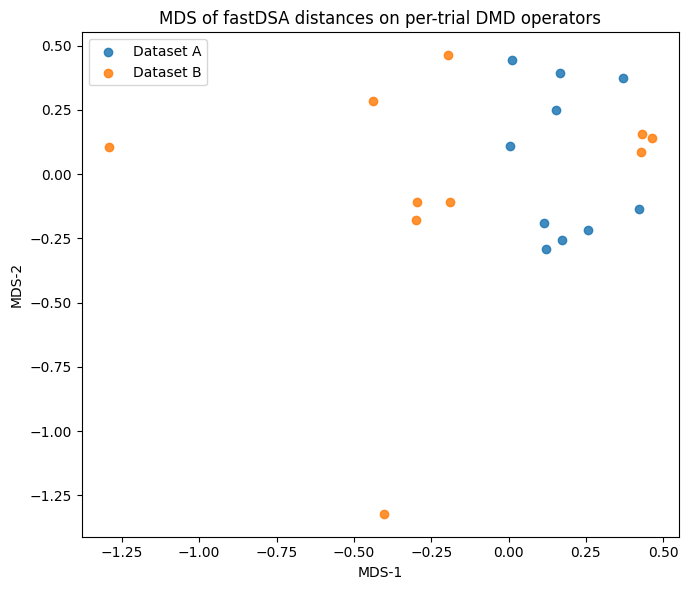

In [9]:
def to_TxC(traj_CxT: np.ndarray) -> np.ndarray:
    """(C,T) -> (T,C)"""
    if traj_CxT.ndim != 2:
        raise ValueError(f"Expected (C,T), got {traj_CxT.shape}")
    return traj_CxT.T

def pad_op_to_dim(A: torch.Tensor, dim: int) -> torch.Tensor:
    """Zero-pad square operator A to (dim, dim)."""
    n = A.shape[0]
    if A.shape[0] != A.shape[1]:
        raise ValueError(f"Operator must be square; got {A.shape}")
    if n == dim:
        return A
    out = torch.zeros((dim, dim), device=A.device, dtype=A.dtype)
    out[:n, :n] = A
    return out

def ensure_torch(A, device: str) -> torch.Tensor:
    """Convert numpy/torch to torch.Tensor on device."""
    if isinstance(A, torch.Tensor):
        return A.to(device)
    return torch.as_tensor(A, dtype=torch.float32, device=device)


# ----------------------------
# Config
# ----------------------------

device = "cuda" if torch.cuda.is_available() else "cpu"

n_delays = 15
delay_interval = 1
steps_ahead = 1

# Metric hyperparams (tune for speed/quality)
iters = 300
lr = 1e-2

# ----------------------------
# 1) Prepare trajectories (T,C) for SVHT and DMD
# ----------------------------

trajs_A = [to_TxC(tr) for tr in dataset_A_ct]  # each (T,C)
trajs_B = [to_TxC(tr) for tr in dataset_B_ct]

# Build Hankel pairs for SVHT rank detection
pairs_A = [delay_embed_traj(tr, n_delays, delay_interval) for tr in trajs_A]
pairs_B = [delay_embed_traj(tr, n_delays, delay_interval) for tr in trajs_B]

ranks_A = svht_ranks_for_pairs(pairs_A, which="X")
ranks_B = svht_ranks_for_pairs(pairs_B, which="X")
global_max_rank = max(max(ranks_A), max(ranks_B))
print("SVHT global_max_rank =", global_max_rank)

# ----------------------------
# 2) Compute DMD operators per trial
# ----------------------------

A_ops, A_used = [], []
for tr in trajs_A:
    Aop, used = compute_dmd_matrix_for_traj(
        tr, n_delays, delay_interval, global_max_rank, device=device, steps_ahead=steps_ahead
    )
    A_ops.append(Aop)
    A_used.append(used)

B_ops, B_used = [], []
for tr in trajs_B:
    Bop, used = compute_dmd_matrix_for_traj(
        tr, n_delays, delay_interval, global_max_rank, device=device, steps_ahead=steps_ahead
    )
    B_ops.append(Bop)
    B_used.append(used)

print("Per-trial ranks used (A) min/max:", min(A_used), max(A_used))
print("Per-trial ranks used (B) min/max:", min(B_used), max(B_used))

# If some trials were capped below global_max_rank, operator sizes may differ.
# We will pad everything to a single max size once (much faster than per-pair padding).
all_ops = A_ops + B_ops
max_dim = max(int(op.shape[0]) for op in all_ops)
print("Padding all operators to dim =", max_dim)

all_ops_pad = [pad_op_to_dim(ensure_torch(op, device), max_dim) for op in all_ops]

# ----------------------------
# 3) Pairwise distance matrix with fDSA
# ----------------------------

N = len(all_ops_pad)
dist_mat = np.zeros((N, N), dtype=float)

# Instantiate the metric object once (assumes fit_score reinitializes internally per call)
fdsa = fDSA(iters=iters, score_method="angular", lr=lr, device=device, verbose=False)

for i in range(N):
    Ai = all_ops_pad[i]
    for j in range(i + 1, N):
        Bj = all_ops_pad[j]
        d = fdsa.fit_score(Ai, Bj)
        dist_mat[i, j] = dist_mat[j, i] = float(d)

print("Distance matrix shape:", dist_mat.shape)

# ----------------------------
# 4) MDS embedding + plot
# ----------------------------

mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
coords = mds.fit_transform(dist_mat)

nA = len(A_ops)
labels = np.array([0] * nA + [1] * (len(B_ops)))

plt.figure(figsize=(7, 6))
plt.scatter(coords[labels == 0, 0], coords[labels == 0, 1], label="Dataset A", alpha=0.85)
plt.scatter(coords[labels == 1, 0], coords[labels == 1, 1], label="Dataset B", alpha=0.85)
plt.xlabel("MDS-1")
plt.ylabel("MDS-2")
plt.title("MDS of fastDSA distances on per-trial DMD operators")
plt.legend()
plt.tight_layout()

plt.savefig("/home/behradarm/Documents/fastDSA/GoNoGo.pdf", bbox_inches="tight")
plt.savefig("/home/behradarm/Documents/fastDSA/GoNoGo.svg", bbox_inches="tight")
plt.show()

In [ ]:
method = 'ro'

device = "cuda" if torch.cuda.is_available() else "cpu"
method = "ro"          # or "rim", "land"
iters = 200
lr = 1e-2
n_delays = 15
delay_interval = 1

all_trials = dataset_A_ct + dataset_B_ct  # each is (C, T)
N = len(all_trials)

# 1) One call to get a global rank (inside your package)
cfg_rank = SimDistConfig(
    n_delays=n_delays,
    delay_interval=delay_interval,
    rank=None,
    method=method,
    iters=50,      # cheap run; rank detection is the point
    lr=lr,
    device=device,
    verbose=True,
)
sim_rank = FastDSASimilarity(cfg_rank)

_, used_rank = sim_rank.fit_score(dataset_A_ct, dataset_B_ct)
print("Global rank selected:", used_rank)

# 2) Pairwise distances with fixed rank
cfg = SimDistConfig(
    n_delays=n_delays,
    delay_interval=delay_interval,
    rank=used_rank,          # fixed for all pairwise calls
    method=method,
    iters=iters,
    lr=lr,
    eta=None,
    gamma=0.98,
    n_Cmats=2,
    device=device,
    verbose=False,
)
sim = FastDSASimilarity(cfg)

dist_mat = np.zeros((N, N), dtype=float)
for i in range(N):
    for j in range(i + 1, N):
        d, _ = sim.fit_score(all_trials[i], all_trials[j])
        dist_mat[i, j] = dist_mat[j, i] = float(d)


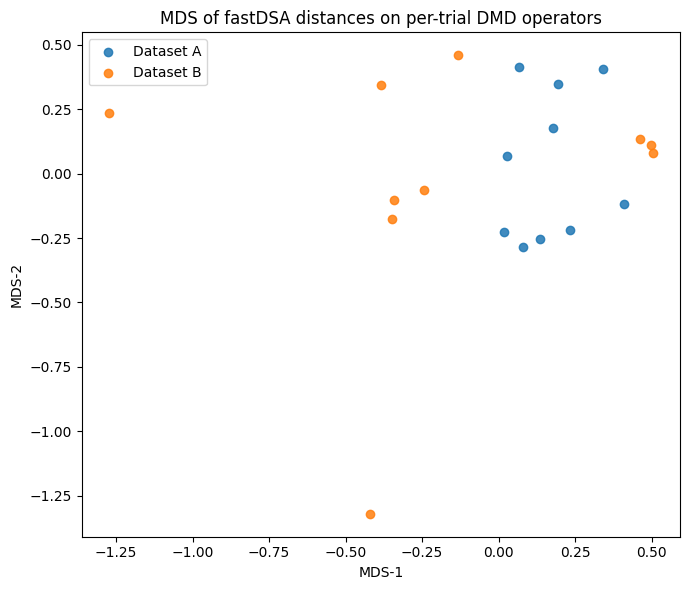

In [14]:

mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
coords = mds.fit_transform(dist_mat)

nA = len(A_ops)
labels = np.array([0] * nA + [1] * (len(B_ops)))

plt.figure(figsize=(7, 6))
plt.scatter(coords[labels == 0, 0], coords[labels == 0, 1], label="Dataset A", alpha=0.85)
plt.scatter(coords[labels == 1, 0], coords[labels == 1, 1], label="Dataset B", alpha=0.85)
plt.xlabel("MDS-1")
plt.ylabel("MDS-2")
plt.title("MDS of fastDSA distances on per-trial DMD operators")
plt.legend()
plt.tight_layout()

plt.savefig("/home/behradarm/Documents/fastDSA/GoNoGo.pdf", bbox_inches="tight")
plt.savefig("/home/behradarm/Documents/fastDSA/GoNoGo.svg", bbox_inches="tight")
plt.show()